In [1]:
# Ensure that we are using the correct host
import socket
try:
    assert "gpu" in socket.gethostname()
    print(f"Running on {socket.gethostname()}. All is good!")
except:
    raise RuntimeError(f"Be sure to run on GPU! You are currently running on {socket.gethostname()}")

Running on gpu41.storrs.hpc.uconn.edu. All is good!


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

In [3]:
base = "/shared/healthinfolab/datasets/ABCD/Irritability/Clinical_Data/Irritability/Release_5.0/"

files = {
    0:  base + "abcd_cbcl_irr_index_release5.0_0m_long.csv",
    12: base + "abcd_cbcl_irr_index_release5.0_12m_long.csv",
    24: base + "abcd_cbcl_irr_index_release5.0_24m_long.csv",
    36: base + "abcd_cbcl_irr_index_release5.0_36m_long.csv",
    48: base + "abcd_cbcl_irr_index_release5.0_48m_long.csv",
}

In [4]:
dfs = []

for t, path in files.items():
    df = pd.read_csv(path)
    df = df[[
        "src_subject_id",
        "cbcl_irr_index_cnst"
    ]].copy()

    df["time"] = t

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [5]:
data = data.rename(columns={
    "src_subject_id": "id",
    "cbcl_irr_index_cnst": "irr"
})

data = data.dropna()

counts = data.groupby("id").size()
valid_ids = counts[counts >= 2].index
data = data[data["id"].isin(valid_ids)]

In [6]:
# choose a small subset of subjects
subset_size = 500

subset_ids = np.random.choice(
    data["id"].unique(),
    size=subset_size,
    replace=False
)

data = data[data["id"].isin(subset_ids)].copy()

In [7]:
ids = data["id"].unique()
id_map = {v:i for i,v in enumerate(ids)}

data["id_i"] = data["id"].map(id_map)

time = data["time"].values
y = data["irr"].values
person = data["id_i"].values

N = len(ids)

In [8]:
K = 4

with pm.Model() as model:
    pi        = pm.Dirichlet("pi", np.ones(K))
    c         = pm.Categorical("c", p=pi, shape=N)
    intercept = pm.Normal("intercept", 0, 3, shape=K)
    slope     = pm.Normal("slope", 0, 1, shape=K)
    sigma     = pm.HalfNormal("sigma", 1)
    mu        = intercept[c[person]] + slope[c[person]] * time
    y_obs     = pm.Normal("y_obs", mu, sigma, observed=y)

    trace = pm.sample(
        500,
        tune=500,
        target_accept=0.9,
        chains=10
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [pi, intercept, slope, sigma]
>CategoricalGibbsMetropolis: [c]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 72 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [9]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c[0],1.746,1.300,0.000,3.000,0.643,0.169,4.0,4.0,2.130000e+01
c[1],1.750,1.299,0.000,3.000,0.644,0.170,4.0,4.0,5.867876e+15
c[2],1.744,1.302,0.000,3.000,0.643,0.167,4.0,4.0,1.444000e+01
c[3],1.750,1.299,0.000,3.000,0.644,0.170,4.0,4.0,5.867876e+15
c[4],1.736,1.294,0.000,3.000,0.622,0.156,4.0,5.0,4.200000e+00
...,...,...,...,...,...,...,...,...,...
pi[0],0.268,0.257,0.025,0.721,0.127,0.071,5.0,30.0,2.420000e+00
pi[1],0.250,0.267,0.024,0.728,0.132,0.074,5.0,35.0,2.840000e+00
pi[2],0.097,0.049,0.018,0.181,0.023,0.011,5.0,30.0,2.380000e+00
pi[3],0.385,0.320,0.022,0.736,0.158,0.011,5.0,33.0,2.170000e+00


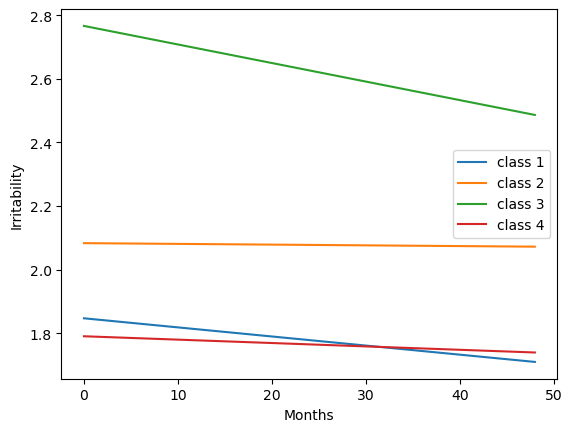

In [10]:
import matplotlib.pyplot as plt

posterior = trace.posterior

inter = posterior["intercept"].mean(("chain","draw")).values
slope = posterior["slope"].mean(("chain","draw")).values

t = np.linspace(0,48,100)

for k in range(K):
    plt.plot(t, inter[k] + slope[k]*t, label=f"class {k+1}")

plt.xlabel("Months")
plt.ylabel("Irritability")
plt.legend()
plt.show()

In [12]:
post = trace.posterior["c"].stack(sample=("chain","draw")).values

classes = post.mean(axis=1).round().astype(int)

class_df = pd.DataFrame({
    "id": ids,
    "class": classes
})

class_df

,id,class
0,NDAR_INV00LH735Y,2
1,NDAR_INV0191C80U,2
2,NDAR_INV02JXJUZG,2
3,NDAR_INV04CLBZAD,2
4,NDAR_INV059VLAHF,2
...,...,...
495,NDAR_INVZB0WCRDU,2
496,NDAR_INVZC64FXGK,2
497,NDAR_INVZEVDMJ6J,2
498,NDAR_INVZJFZNNPJ,2
